In [1]:
import numpy as np
from scipy import constants
import pandas as pd
pd.set_option('display.width', 10000) # Adjust for desired width
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None) # display full content in a column
import matplotlib.pyplot as plt
from tweezer_functions import * 
from IonChainTools import *
from scipy.optimize import fsolve
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar
from scipy.optimize import fsolve
from scipy.optimize import curve_fit
from scipy.optimize import minimize
import matplotlib.ticker as ticker
import itertools
import math

#Constants in SI units
eps0 = constants.epsilon_0 
m = 39.9626*constants.atomic_mass
c = constants.c
e = constants.e
hbar = constants.hbar
pi = np.pi

# setting up parameters that we're not changing
qubit_wavelength = 729e-9
tweezer_wavelength = 532e-9
omega_tweezer = 2*pi*c/tweezer_wavelength
print(omega_tweezer)
df = pd.read_csv("S_P_only.csv",sep = ",",encoding = "UTF-8")
lambdares = np.array(df["wavelength (nm)"])*1e-9
omega_res = 2*pi*c/lambdares
linewidths = np.array(df["A_ki (s^-1)"])
lifetimes = linewidths
print(linewidths)
#test

3540698434791077.0
[1.47e+08 1.40e+08]


# brute force calculation of every single ion coupling to every single mode -- radial only

In [2]:
N = np.arange(3,4)
P = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3
N3= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P,
    w0,
    max_tweezed=1,
)
result = build_mode_series_and_combinations(N3)
mode0_list = result["mode_lists"][0]
print(mode0_list)
mode1_list = result["mode_lists"][1]
print(mode1_list)
mode2_list = result["mode_lists"][2]
print(mode2_list)

untweezed = combine_lists(mode0_list, mode1_list, mode2_list)[np.nan]
tweeze0 = combine_lists(mode0_list, mode1_list, mode2_list)[0]
tweeze1 = combine_lists(mode0_list, mode1_list, mode2_list)[1]
tweeze2 = combine_lists(mode0_list, mode1_list, mode2_list)[2]

min_untweezed = condense_by_min_abs(untweezed)
min_tweeze_0 = condense_by_min_abs(tweeze0)
min_tweeze_1 = condense_by_min_abs(tweeze1)
min_tweeze_2 = condense_by_min_abs(tweeze2)

best_untweezed = filter_by_max_min_abs(min_untweezed)
best_tweeze_0 = filter_by_max_min_abs(min_tweeze_0)
best_tweeze_1 = filter_by_max_min_abs(min_tweeze_1)
best_tweeze_2 = filter_by_max_min_abs(min_tweeze_2)
print(best_tweeze_0)
print(best_tweeze_1)
print(best_tweeze_2)
select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2])
print(select_global_max_min_abs([best_untweezed, best_tweeze_0, best_tweeze_1, best_tweeze_2]))


[(nan, array([0.57735027, 0.57735027, 0.57735027])), (0, array([-0.99975899, -0.0217139 , -0.00323688])), (1, array([0.02254184, 0.99949174, 0.02254184])), (2, array([0.00323688, 0.0217139 , 0.99975899]))]
[(nan, array([ 7.07106781e-01, -1.76373406e-13, -7.07106781e-01])), (0, array([-0.01451165,  0.54298991,  0.83961382])), (1, array([ 0.70674738, -0.03187897,  0.70674738])), (2, array([-0.83961382, -0.54298991,  0.01451165]))]
[(nan, array([-0.40824829,  0.81649658, -0.40824829])), (0, array([ 0.0164737 , -0.83945844,  0.54317415])), (1, array([-7.07106781e-01, -1.83901055e-14,  7.07106781e-01])), (2, array([ 0.54317415, -0.83945844,  0.0164737 ]))]
[(0, (0, 2, 1), -0.8394584355453282)]
[(1, (1, 0, 2), 0.7067473845006338)]
[(2, (2, 0, 1), -0.8394584355453685)]
[(0, (0, 2, 1), -0.8394584355453282), (2, (2, 0, 1), -0.8394584355453685)]


In [4]:
N3

,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode1_freq,Mode1_eigvec,Mode2_freq,Mode2_eigvec
0,3,(),0.0,"[6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.5773502691896842, 0.5773502691895966, 0.5773502691895965]",998591.769782,"[0.7071067811865628, -1.7637340627392875e-13, -0.7071067811865324]",996616.904544,"[-0.4082482904637448, 0.8164965809277465, -0.4082482904639407]"
1,3,"(0,)",0.1,"[6595799.989691874, 6283185.307179586, 6283185.307179586]",1.048571e+06,"[-0.9997589855694827, -0.02171389850257122, -0.0032368788823396786]",999458.971232,"[-0.014511653546581162, 0.542989909301837, 0.8396138221276058]",996993.358994,"[0.016473696744292242, -0.8394584355453282, 0.5431741454702784]"
2,3,"(1,)",0.1,"[6283185.307179586, 6595799.989691874, 6283185.307179586]",1.047656e+06,"[0.022541838926842594, 0.999491736331818, 0.02254183892684892]",998822.735489,"[0.7067473845006338, -0.03187897433117449, 0.7067473844996569]",998591.769782,"[-0.7071067811862348, -1.8390105536749736e-14, 0.7071067811868603]"
3,3,"(2,)",0.1,"[6283185.307179586, 6283185.307179586, 6595799.989691874]",1.048571e+06,"[0.003236878882339686, 0.02171389850257437, 0.9997589855694826]",999458.971232,"[-0.8396138221276488, -0.5429899093017705, 0.014511653546581613]",996993.358994,"[0.5431741454702161, -0.8394584355453685, 0.016473696744295923]"


In [14]:
# ...existing code...
import numpy as np
import ast
import pandas as pd

def add_eigvec_quadrature_columns(df, eigvec_suffix='_eigvec', out_suffix='_norm', decimals=4, add_formatted_string=True):
    """
    For every column in df whose name ends with eigvec_suffix compute per-row
    quadrature norm = sqrt(sum(x_i**2)) and insert a new column next to it
    named <orig_col><out_suffix> (numeric, rounded to `decimals`).
    If add_formatted_string is True also add <orig_col><out_suffix>_fmt
    containing a fixed-width string with exactly `decimals` digits (e.g. '0.9899')
    which avoids pandas / notebook display collapsing to fewer decimals.
    """
    df = df.copy()
    cols = list(df.columns)
    computed = {}          # numeric rounded values
    computed_str = {}      # formatted strings

    for col in cols:
        if not col.endswith(eigvec_suffix):
            continue
        nums = []
        strs = []
        for v in df[col].to_numpy():
            if v is None or (isinstance(v, float) and np.isnan(v)):
                nums.append(np.nan)
                strs.append(np.nan)
                continue
            if isinstance(v, str):
                try:
                    v_parsed = ast.literal_eval(v)
                except Exception:
                    v_parsed = None
            else:
                v_parsed = v
            try:
                arr = np.asarray(v_parsed, dtype=float)
                norm = float(np.linalg.norm(arr))
                # round numeric value
                norm_rounded = float(np.round(norm, decimals))
                nums.append(norm_rounded)
                # formatted string with fixed decimals
                if add_formatted_string:
                    strs.append(f"{norm_rounded:.{decimals}f}")
            except Exception:
                nums.append(np.nan)
                strs.append(np.nan)
        computed[f"{col}{out_suffix}"] = nums
        if add_formatted_string:
            computed[f"{col}{out_suffix}_fmt"] = strs

    # insert new columns next to originals (preserve order)
    out = pd.DataFrame()
    for col in cols:
        out[col] = df[col]
        if col.endswith(eigvec_suffix):
            out_col = f"{col}{out_suffix}"
            out[out_col] = computed.get(out_col)
            if add_formatted_string:
                out[f"{out_col}_fmt"] = computed.get(f"{out_col}_fmt")

    # add any remaining computed keys (safety)
    for k, v in computed.items():
        if k not in out.columns:
            out[k] = v
    return out
# ...existing code...

In [15]:
add_eigvec_quadrature_columns(N3)

,N,Tweezed ions,P_per_tweezer (W),Combined radial frequencies,Mode0_freq,Mode0_eigvec,Mode0_eigvec_norm,Mode0_eigvec_norm_fmt,Mode1_freq,Mode1_eigvec,Mode1_eigvec_norm,Mode1_eigvec_norm_fmt,Mode2_freq,Mode2_eigvec,Mode2_eigvec_norm,Mode2_eigvec_norm_fmt
0,3,(),0.0,"[6283185.307179586, 6283185.307179586, 6283185.307179586]",1.000000e+06,"[0.5773502691896842, 0.5773502691895966, 0.5773502691895965]",1.0,1.0000,998591.769782,"[0.7071067811865628, -1.7637340627392875e-13, -0.7071067811865324]",1.0,1.0000,996616.904544,"[-0.4082482904637448, 0.8164965809277465, -0.4082482904639407]",1.0,1.0000
1,3,"(0,)",0.1,"[6595799.989691874, 6283185.307179586, 6283185.307179586]",1.048571e+06,"[-0.9997589855694827, -0.02171389850257122, -0.0032368788823396786]",1.0,1.0000,999458.971232,"[-0.014511653546581162, 0.542989909301837, 0.8396138221276058]",1.0,1.0000,996993.358994,"[0.016473696744292242, -0.8394584355453282, 0.5431741454702784]",1.0,1.0000
2,3,"(1,)",0.1,"[6283185.307179586, 6595799.989691874, 6283185.307179586]",1.047656e+06,"[0.022541838926842594, 0.999491736331818, 0.02254183892684892]",1.0,1.0000,998822.735489,"[0.7067473845006338, -0.03187897433117449, 0.7067473844996569]",1.0,1.0000,998591.769782,"[-0.7071067811862348, -1.8390105536749736e-14, 0.7071067811868603]",1.0,1.0000
3,3,"(2,)",0.1,"[6283185.307179586, 6283185.307179586, 6595799.989691874]",1.048571e+06,"[0.003236878882339686, 0.02171389850257437, 0.9997589855694826]",1.0,1.0000,999458.971232,"[-0.8396138221276488, -0.5429899093017705, 0.014511653546581613]",1.0,1.0000,996993.358994,"[0.5431741454702161, -0.8394584355453685, 0.016473696744295923]",1.0,1.0000


In [10]:
(0.7**2+0.7**2)**(1/2)

0.9899494936611665

In [11]:
(0.408**2+0.816**2+0.405**2)**(1/2)

0.9981708270631835

In [71]:
def run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.
    
    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index)), ...]
    """
    
    # 1. Build eigenvector lists for all configurations
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=max_tweezed
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- CLEAN: remove unusable keys ----
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v
    mode_lists_dict = cleaned
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices and collect all mode lists
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))

    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 3. Combine modes across all tweezed ions
    combos = combine_lists(*mode_lists_ordered)
    
    # 4. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 5. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 6. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))

  # 7. Compute best ion/mode indices properly
    augmented = []
    for tweezed_ion, mapping, score in winners:
        # Access the corresponding values from combos
        values = None
        for t, combo_indices, arr in combos[tweezed_ion]:
            if combo_indices == mapping:
                values = arr
                break
        
        if values is None:
            # fallback: use mapping itself (less accurate)
            values = np.array(mapping)
        
        # best ion index = position in vector responsible for min(abs) (i.e., score)
        best_ion_index = int(np.argmin(np.abs(values)))
        best_mode_index = mapping[best_ion_index]

        # ✅ ADD P_opt BACK INTO THE RETURNED STRUCTURE
        augmented.append(
            ((tweezed_ion, mapping, score, P_opt), (best_ion_index, best_mode_index))
        )

    return augmented





import numpy as np
import math

def run_optimal_mode_selection_untweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0
):
    """
    Run optimal mode selection for the untweezed configuration only.
    
    Returns:
        winners: list of tuples
                 [(None, ion_to_mode_mapping, max_of_min_abs), ...]
    """
    
    # 1. Build eigenvector lists for the untweezed configuration
    df = tweezer_combos_full_radial(
        omega_tweezer, linewidths, omega_res, m,
        mode_calc_r, N, f_rf_r, f_rf_a, P_opt, w0,
        max_tweezed=0
    )
    
    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]
    
    # ---- FIX SECTION ----
    # remove unusable keys (nan, None, empty tuples)
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v

    mode_lists_dict = cleaned
    # ---- END FIX ----
    
    if not mode_lists_dict:
        return []
    
    # 2. Sort mode indices numerically if possible
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        # fallback: sort by string representation
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))
    
    if not mode_indices:
        return []
    
    # 3. Collect lists in canonical order
    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]
    
    # 4. Combine modes
    combos = combine_lists(*mode_lists_ordered)
    
    # 5. Condense by min(abs)
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}
    
    # 6. Filter by max(min(abs)) within each group
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}
    
    # 7. Select global winners
    winners = select_global_max_min_abs(list(best_each.values()))
    
    # 8. Add placeholder for "none tweezed"
    winners = [(None, combo, val) for _, combo, val in winners]

    #can remove this later but this is just to make sure it all works
    print("Keys:", list(mode_lists_dict.keys()))
    
    return winners




DO NOT NAME ANYTHING ELSE RESULTS OR UNTWEEZED RESULTS OR TRY TO RUN THE CODE BLOCK UNDERNEATH THIS AGAIN. BOTH OF THEM TAKE LIKE 20 MINUTES

In [72]:
P_opt = [100e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=1,
    )
    results.append((Ni, winners))


In [73]:
Power = [100]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

results_high_P = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_tweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        Power,
        w0,
        max_tweezed=1,
    )
    results_high_P.append((Ni, winners))

In [74]:
untweezed_results = []
for Ni in range(2, 8):
    winners = run_optimal_mode_selection_untweezed_only(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
    )
    untweezed_results.append((Ni, winners))


Keys: [0, 1]
Keys: [0, 1, 2]
Keys: [0, 1, 2, 3]
Keys: [0, 1, 2, 3, 4]
Keys: [0, 1, 2, 3, 4, 5]
Keys: [0, 1, 2, 3, 4, 5, 6]


In [75]:
results

[(2,
  [((0, (0, 1), 0.9999048485013973, [0.1]), (0, 0)),
   ((1, (1, 0), 0.9999048485013973, [0.1]), (0, 1))]),
 (3,
  [((0, (0, 2, 1), -0.8394584355453282, [0.1]), (2, 1)),
   ((2, (2, 0, 1), -0.8394584355453685, [0.1]), (2, 1))]),
 (4,
  [((1, (1, 3, 0, 2), -0.8667132198367613, [0.1]), (1, 3)),
   ((2, (2, 0, 3, 1), 0.866713219836582, [0.1]), (1, 0))]),
 (5,
  [((2, (2, 0, 4, 3, 1), -0.6234865428010057, [0.1]), (3, 3)),
   ((2, (2, 4, 0, 3, 1), -0.6234865428010057, [0.1]), (3, 3))]),
 (6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147804, [0.1]), (3, 4))]),
 (7, [((4, (4, 0, 6, 2, 5, 1, 3), -0.5566105567295492, [0.1]), (3, 2))])]

In [76]:
results_high_P

[(2,
  [((0, (0, 1), 0.9999999999047988, [100]), (0, 0)),
   ((1, (1, 0), 0.9999999999047988, [100]), (0, 1))]),
 (3,
  [((0, (0, 2, 1), -0.8369074374402578, [100]), (2, 1)),
   ((2, (2, 0, 1), 0.8369074374402845, [100]), (2, 1))]),
 (4,
  [((1, (1, 3, 0, 2), 0.8547427658747804, [100]), (1, 3)),
   ((2, (2, 0, 3, 1), 0.8547427658746907, [100]), (1, 0))]),
 (5,
  [((2, (2, 0, 4, 3, 1), 0.6154669457120358, [100]), (3, 3)),
   ((2, (2, 4, 0, 3, 1), 0.6154669457120358, [100]), (3, 3))]),
 (6, [((3, (3, 0, 5, 2, 4, 1), -0.5756239010509402, [100]), (3, 2))]),
 (7, [((4, (4, 0, 6, 2, 5, 1, 3), 0.5459005626807186, [100]), (3, 2))])]

In [77]:
untweezed_results

[(2, [(None, (0, 1), 0.7071067811865476), (None, (1, 0), 0.7071067811865476)]),
 (3, [(None, (0, 2, 1), 0.5773502691896842)]),
 (4, [(None, (1, 3, 0, 2), 0.5000000000000102)]),
 (5,
  [(None, (3, 0, 4, 1, 2), 0.44721359550000983),
   (None, (3, 4, 0, 1, 2), 0.44721359550000983)]),
 (6,
  [(None, (5, 0, 2, 1, 4, 3), 0.40824829046388145),
   (None, (5, 0, 2, 4, 1, 3), 0.40824829046388145),
   (None, (5, 0, 3, 1, 4, 2), 0.40824829046388145),
   (None, (5, 0, 3, 4, 1, 2), 0.40824829046388145)]),
 (7,
  [(None, (1, 0, 3, 6, 5, 2, 4), 0.37796447300929525),
   (None, (1, 0, 3, 6, 5, 4, 2), 0.37796447300929525),
   (None, (1, 0, 6, 2, 3, 5, 4), 0.37796447300929525),
   (None, (1, 0, 6, 2, 5, 4, 3), 0.37796447300929525),
   (None, (1, 0, 6, 4, 3, 5, 2), 0.37796447300929525),
   (None, (1, 0, 6, 4, 5, 2, 3), 0.37796447300929525),
   (None, (1, 0, 6, 5, 3, 2, 4), 0.37796447300929525),
   (None, (1, 0, 6, 5, 3, 4, 2), 0.37796447300929525),
   (None, (1, 6, 0, 2, 3, 5, 4), 0.37796447300929525),
   

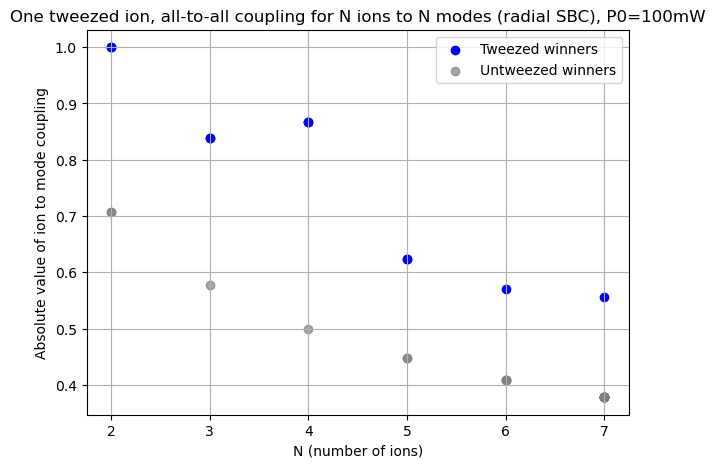

In [80]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

def _extract_score_from_win(win):
    """Return numeric score from a winner entry or None if not found."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), (best_ion, best_mode))
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def _extract_tweezed_ion(win):
    """Return tweezed ion index (or None) from a winner entry."""
    if not isinstance(win, (list, tuple)):
        return None
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 1:
        return win[0][0]
    return win[0]

# Tweezed winners only
x_tweezed = []
y_tweezed = []

for N_val, winners in results:
    if not winners:
        continue
    for win in winners:
        tweezed_ion = _extract_tweezed_ion(win)
        if tweezed_ion is None:
            continue   # skip untweezed
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_tweezed.append(N_val)
        y_tweezed.append(abs(score))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        score = _extract_score_from_win(win)
        if score is None:
            continue
        x_untweezed.append(N_val)
        y_untweezed.append(abs(score))

# Convert to arrays (safe if empty)
x_tweezed = np.asarray(x_tweezed, dtype=float)
y_tweezed = np.asarray(y_tweezed, dtype=float)
x_untweezed = np.asarray(x_untweezed, dtype=float)
y_untweezed = np.asarray(y_untweezed, dtype=float)

# Plot
plt.figure(figsize=(7,5))
plt.scatter(x_tweezed, y_tweezed, color='blue', label='Tweezed winners')
plt.scatter(x_untweezed, y_untweezed, color='gray', label='Untweezed winners', alpha=0.7)

plt.xlabel("N (number of ions)")
plt.ylabel("Absolute value of ion to mode coupling")
plt.title("One tweezed ion, all-to-all coupling for N ions to N modes (radial SBC), P0=100mW")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

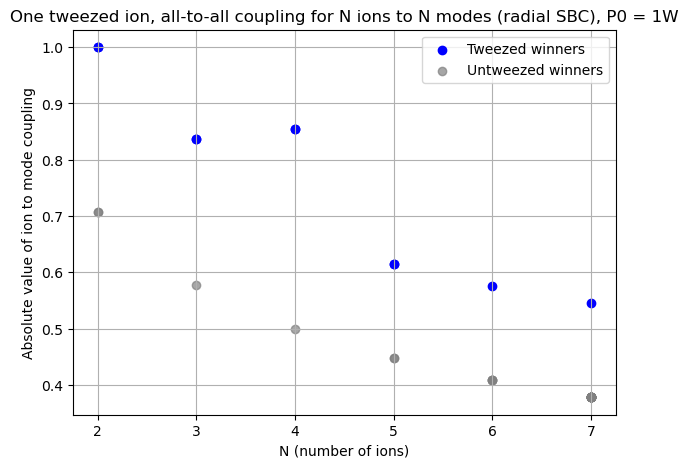

In [81]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

def _extract_score(win):
    """Return numeric score from various winner formats, or None."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), (best_ion, best_mode))
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def _extract_tweezed_ion(win):
    """Return tweezed ion index (or None) from winner entry."""
    if not isinstance(win, (list, tuple)):
        return None
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 1:
        return win[0][0]
    return win[0]  # may be None for untweezed entries

# --- Prepare data for plotting ---

# Tweezed winners (results_high_P)
x_tweezed = []
y_tweezed = []

for N_val, winners in results_high_P:
    if not winners:
        continue
    for win in winners:
        score = _extract_score(win)
        tweezed_ion = _extract_tweezed_ion(win)
        if score is None:
            continue
        # only include entries that are actually tweezed
        if tweezed_ion is None:
            continue
        x_tweezed.append(N_val)
        y_tweezed.append(abs(score))

# Untweezed winners
x_untweezed = []
y_untweezed = []

for N_val, winners in untweezed_results:
    if not winners:
        continue
    for win in winners:
        score = _extract_score(win)
        if score is None:
            continue
        x_untweezed.append(N_val)
        y_untweezed.append(abs(score))

# Convert to arrays (safe if empty)
x_tweezed = np.asarray(x_tweezed, dtype=float)
y_tweezed = np.asarray(y_tweezed, dtype=float)
x_untweezed = np.asarray(x_untweezed, dtype=float)
y_untweezed = np.asarray(y_untweezed, dtype=float)

# --- Plot ---
plt.figure(figsize=(7,5))
plt.scatter(x_tweezed, y_tweezed, color='blue', label='Tweezed winners')
plt.scatter(x_untweezed, y_untweezed, color='gray', label='Untweezed winners', alpha=0.7)

plt.xlabel("N (number of ions)")
plt.ylabel("Absolute value of ion to mode coupling")
plt.title("One tweezed ion, all-to-all coupling for N ions to N modes (radial SBC), P0 = 1W")
plt.grid(True)
plt.legend()
plt.show()
# ...existing code...

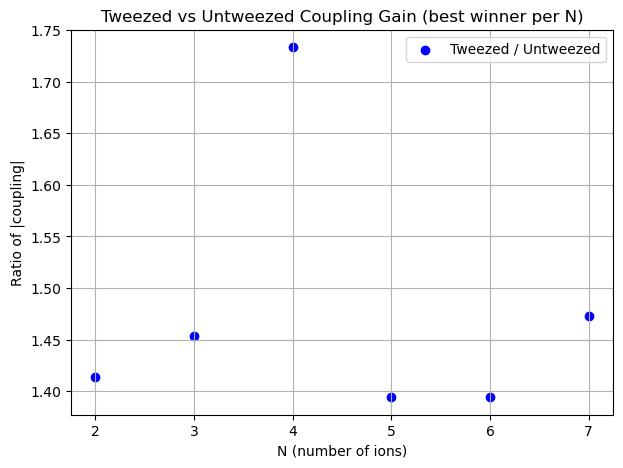

In [82]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt

def _get_score_from_win(win):
    """Return numeric score from winner entry (handles nested and flat formats)."""
    if not isinstance(win, (list, tuple)):
        return None
    # nested format: ((ion, mapping, score), ...)
    if isinstance(win[0], (list, tuple)) and len(win[0]) >= 3:
        return win[0][2]
    # flat format: (tweezed_ion, mapping, score, ...)
    if len(win) >= 3:
        return win[2]
    return None

def best_per_N(results):
    """Return arrays (N_values, best_abs_score) picking best winner per N robustly."""
    Ns = []
    vals = []
    for N_val, winners in results:
        if not winners:
            continue
        scores = []
        for win in winners:
            s = _get_score_from_win(win)
            if s is None:
                continue
            scores.append(s)
        if not scores:
            continue
        best_score = max(scores, key=lambda s: abs(s))
        Ns.append(N_val)
        vals.append(abs(best_score))
    return np.asarray(Ns), np.asarray(vals)

# --- Compute best-per-N for tweezed and untweezed ---
x_tweezed_best, y_tweezed_best = best_per_N(results)
x_untweezed_best, y_untweezed_best = best_per_N(untweezed_results)

# Align on common N and compute ratio (avoid divide-by-zero)
common_N = np.intersect1d(x_tweezed_best, x_untweezed_best)
if common_N.size == 0:
    print("No common N between tweezed and untweezed results — nothing to plot.")
else:
    # build lookup maps to align values
    map_t = {n: v for n, v in zip(x_tweezed_best, y_tweezed_best)}
    map_u = {n: v for n, v in zip(x_untweezed_best, y_untweezed_best)}
    common_N = np.sort(common_N)
    y_t_aligned = np.array([map_t[n] for n in common_N], dtype=float)
    y_u_aligned = np.array([map_u[n] for n in common_N], dtype=float)

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.where(y_u_aligned == 0, np.nan, y_t_aligned / y_u_aligned)

    # --- Plot ---
    plt.figure(figsize=(7,5))
    plt.scatter(common_N, ratio, color='blue', label='Tweezed / Untweezed')
    plt.xlabel("N (number of ions)")
    plt.ylabel("Ratio of |coupling|")
    plt.title("Tweezed vs Untweezed Coupling Gain (best winner per N)")
    plt.grid(True)
    plt.legend()
    plt.show()
# ...existing code...

## Showing the optimal configuration for N = 5


In [83]:
print(results[5-2])

(5, [((2, (2, 0, 4, 3, 1), -0.6234865428010057, [0.1]), (3, 3)), ((2, (2, 4, 0, 3, 1), -0.6234865428010057, [0.1]), (3, 3))])


In [17]:
N = 5
f_rf_r = 1e6
w_rf_a = f_rf_r/3 * 2*pi
indices = (2,0,4,3,1)
tweezed_ions = 2
w_rf_r = f_rf_r * 2 * np.pi

ueq = ion_spacing(N,w_rf_a)[0]

w0 = 1e-6
P0 = 10e-3


U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
w_tw_r = omega_tweezer_r(U,w0,m)

w_rf_combined = np.full((N,), w_rf_r)
w_rf_combined[tweezed_ions] = np.sqrt(w_tw_r**2 + w_rf_r**2)

data_N5 = mode_calc_r(m,w_rf_combined,ueq,N)
print(data_N5)




[(1001037.8417741434, array([0.44294159, 0.44737458, 0.45532129, 0.44737458, 0.44294159])), (942809.0416398385, array([-6.39533026e-01, -3.01657934e-01, -2.67932701e-12,  3.01657934e-01,
        6.39533026e-01])), (857357.0912213165, array([-0.54064761,  0.27227597,  0.51684806,  0.27227597, -0.54064761])), (732872.8354910596, array([-3.01657934e-01,  6.39533026e-01,  1.16225061e-11, -6.39533026e-01,
        3.01657934e-01])), (558895.4661621104, array([ 0.10725163, -0.47510187,  0.72494869, -0.47510187,  0.10725163]))]


In [23]:
def run_optimal_mode_selection_tweezed_only(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_opt,
    w0,
    max_tweezed=1
):
    """
    Run optimal mode selection for all tweezed configurations only.

    Returns:
        winners: list of tuples
                 [((tweezed_ion, mapping, max_of_min_abs), (best_ion_index, best_mode_index))]
    """

    # -----------------------------------------------------------
    # 1. Build eigenvector lists for all tweezed configurations
    # -----------------------------------------------------------
    df = tweezer_combos_full_radial(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P_opt,
        w0,
        max_tweezed=max_tweezed
    )

    result = build_mode_series_and_combinations(df)
    mode_lists_dict = result["mode_lists"]

    # -----------------------------------------------------------
    # CLEAN unusable keys
    # -----------------------------------------------------------
    cleaned = {}
    for k, v in mode_lists_dict.items():
        if k is None:
            continue
        if isinstance(k, float) and math.isnan(k):
            continue
        if k == ():
            continue
        cleaned[k] = v
    mode_lists_dict = cleaned

    if not mode_lists_dict:
        return []

    # -----------------------------------------------------------
    # 2. Sort mode indices
    # -----------------------------------------------------------
    try:
        mode_indices = sorted(mode_lists_dict.keys())
    except TypeError:
        mode_indices = sorted(mode_lists_dict.keys(), key=lambda x: str(x))

    mode_lists_ordered = [mode_lists_dict[i] for i in mode_indices]

    # -----------------------------------------------------------
    # 3. Combine modes across tweezed ions
    # -----------------------------------------------------------
    combos = combine_lists(*mode_lists_ordered)

    # -----------------------------------------------------------
    # 4. Condense each combination by min(|value|)
    # -----------------------------------------------------------
    condensed = {k: condense_by_min_abs(v) for k, v in combos.items()}

    # -----------------------------------------------------------
    # 5. Filter inside each group by max(min(|value|))
    # -----------------------------------------------------------
    best_each = {k: filter_by_max_min_abs(v) for k, v in condensed.items()}

    # -----------------------------------------------------------
    # 6. Select global winners (max over all groups)
    # -----------------------------------------------------------
    winners = select_global_max_min_abs(list(best_each.values()))

    # -----------------------------------------------------------
    # 7. Determine best ion index + best mode index for each
    # -----------------------------------------------------------
    augmented = []

    for tweezed_ion, mapping, score in winners:

        # Find the matching array in combos
        values = None
        for (t, combo_indices, arr) in combos[tweezed_ion]:
            if combo_indices == mapping:
                values = arr
                break

        if values is None:  # fallback
            values = np.array(mapping)

        # best ion is the one giving min(abs(value))
        best_ion_index = int(np.argmin(np.abs(values)))
        best_mode_index = mapping[best_ion_index]

        augmented.append(
            ((tweezed_ion, mapping, score), (best_ion_index, best_mode_index))
        )

    return augmented


In [19]:
def run_optimal_mode_selection_tweezed_power_sweep(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
):
    """
    Sweep over a list of powers and run optimal mode selection
    for tweezed configurations only using run_optimal_mode_selection_tweezed_only.

    Returns:
        power_results: list of tuples [(P_opt, winners), ...]
    """
    power_results = []

    for P_opt in P_list:
        winners = run_optimal_mode_selection_tweezed_only(
            omega_tweezer,
            linewidths,
            omega_res,
            m,
            mode_calc_r,
            N,
            f_rf_r,
            f_rf_a,
            P_opt,
            w0,
            max_tweezed=max_tweezed
        )
        power_results.append((P_opt, winners))

    return power_results


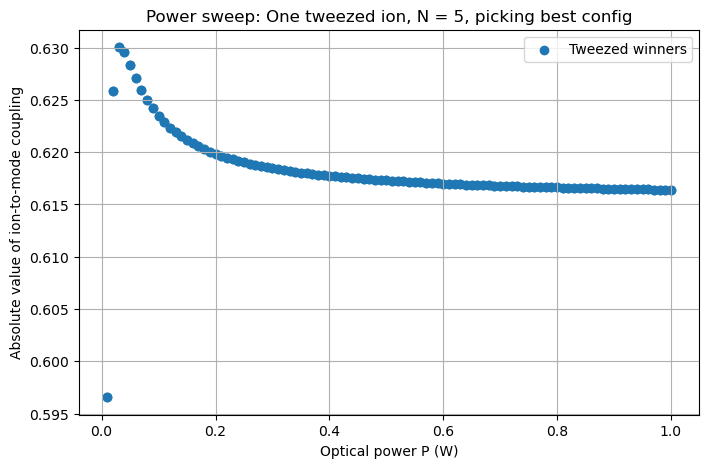

In [24]:
import numpy as np
import matplotlib.pyplot as plt

# --- prepare power list (don't reuse the name P_opt) ---
P_list = np.linspace(10e-3, 1.0, 100)  # 0.01 .. 1.0 W
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3.0

# --- run sweep for desired N values (here only N=5) ---
results_power_sweep_5 = []
for Ni in range(5, 6):
    # call with the whole list of powers
    power_results = run_optimal_mode_selection_tweezed_power_sweep(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        Ni,
        f_rf_r,
        f_rf_a,
        P_list,   # <-- pass the list, not a scalar
        w0,
        max_tweezed=1,
    )
    # store (N, power_results)
    results_power_sweep_5.append((Ni, power_results))


# --- extract plotting arrays ---
x_tweezed = []
y_tweezed = []

# results_power_sweep_5: [(N, [(P_opt, winners), ...]), ...]
for Ni, power_results in results_power_sweep_5:
    for P_opt, winners in power_results:
        if not winners:
            continue
        # winners is a list of winner entries returned by run_optimal_mode_selection_tweezed_only
        # each winner has format: ((tweezed_ion, mapping, score), (best_ion, best_mode))
        for outer, inner in winners:
            # outer == (tweezed_ion, mapping, score)
            tweezed_ion, mapping, score = outer
            # inner == (best_ion, best_mode)
            # If you only want actual tweezed results (not None), guard:
            if tweezed_ion is None:
                continue
            x_tweezed.append(P_opt)
            y_tweezed.append(abs(score))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

# --- plot ---
plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, y_tweezed, marker='o', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Absolute value of ion-to-mode coupling")
plt.title("Power sweep: One tweezed ion, N = 5, picking best config")
plt.grid(True)
plt.legend()
plt.show()


In [25]:
results_power_sweep_5

[(5,
  [(0.01,
    [((2, (2, 0, 4, 3, 1), -0.5965657241798762), (4, 1)),
     ((2, (2, 4, 0, 3, 1), -0.5965657241798762), (4, 1))]),
   (0.02,
    [((2, (2, 0, 4, 3, 1), -0.6258612099205998), (4, 1)),
     ((2, (2, 4, 0, 3, 1), -0.6258612099205998), (4, 1))]),
   (0.03,
    [((2, (2, 0, 4, 3, 1), 0.6300406376377148), (4, 1)),
     ((2, (2, 4, 0, 3, 1), 0.6300406376377148), (4, 1))]),
   (0.04,
    [((2, (2, 0, 4, 3, 1), -0.6296080641207955), (4, 1)),
     ((2, (2, 4, 0, 3, 1), -0.6296080641207955), (4, 1))]),
   (0.05,
    [((2, (2, 0, 4, 3, 1), -0.6283622512153321), (3, 3)),
     ((2, (2, 4, 0, 3, 1), -0.6283622512153321), (3, 3))]),
   (0.060000000000000005,
    [((2, (2, 0, 4, 3, 1), -0.6270944099267008), (3, 3)),
     ((2, (2, 4, 0, 3, 1), -0.6270944099267008), (3, 3))]),
   (0.06999999999999999,
    [((2, (2, 0, 4, 3, 1), -0.6259702996755103), (3, 3)),
     ((2, (2, 4, 0, 3, 1), -0.6259702996755103), (3, 3))]),
   (0.08,
    [((2, (2, 0, 4, 3, 1), -0.6250071928909647), (3, 3)),
  

## Showing the optimal configuration for N=6

In [87]:
print(results[6-2])
#print(results_high_P[6-2])
#print(untweezed_results[6-2])

(6, [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147804, [0.1]), (3, 4))])


In [88]:
N = 6
f_rf_r = 1e6
w_rf_a = f_rf_r/3 * 2*pi
indices = (2,5,0,4,1,3)
tweezed_ions = 2
w_rf_r = f_rf_r * 2 * np.pi

ueq = ion_spacing(N,w_rf_a)[0]

w0 = 1e-6
P0 = 1


U = potential(omega_tweezer,linewidths,omega_res,P0,w0)
w_tw_r = omega_tweezer_r(U,w0,m)

w_rf_combined = np.full((N,), w_rf_r)
w_rf_combined[tweezed_ions] = np.sqrt(w_tw_r**2 + w_rf_r**2)

data_N6 = mode_calc_r(m,w_rf_combined,ueq,N)
print(data_N6)

[(1255704.40136543, array([0.0845683 , 0.2438689 , 0.92793597, 0.24760568, 0.09713705,
       0.03958305])), (951351.2556375064, array([-0.11404744, -0.08830807, -0.11425732,  0.22505008,  0.50855099,
        0.81047423])), (924088.6109673298, array([-0.91227995, -0.34467261,  0.17387834,  0.03560102, -0.0410669 ,
       -0.1255328 ])), (769055.9334767961, array([-0.07909169,  0.1073797 ,  0.15816996, -0.51771072, -0.61794036,
        0.55436603])), (645392.1744376079, array([ 0.37547283, -0.89317837,  0.20355198,  0.02927549, -0.12614056,
        0.05523262])), (422526.7754875689, array([-0.01874388,  0.06806193, -0.17086626,  0.78606298, -0.57662125,
        0.12423316]))]


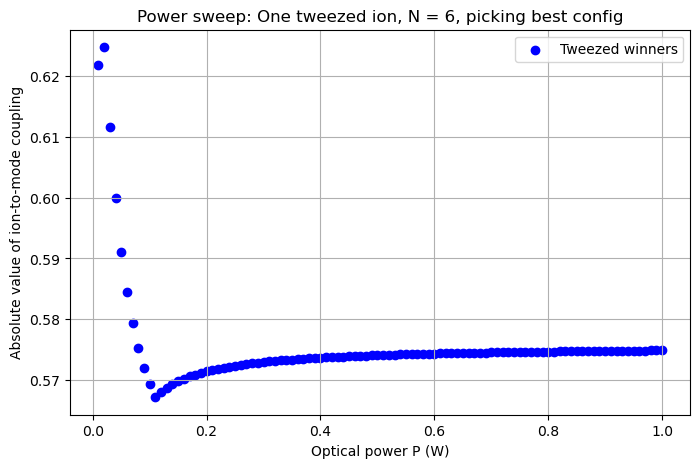

In [27]:
import numpy as np
import matplotlib.pyplot as plt

# --- Parameters ---
N = 6
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r / 3
P_list = np.linspace(10e-3, 1, 100)  # optical powers from 10 mW to 1 W

# --- Run power sweep using your tweezed-only function ---
results_power_sweep_6 = run_optimal_mode_selection_tweezed_power_sweep(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P_list,
    w0,
    max_tweezed=1
)

# --- Prepare data for plotting ---
x_tweezed = []
y_tweezed = []

for P_opt, winners in results_power_sweep_6:
    if not winners:
        continue
    for (tweezed_ion, mapping, val), (best_ion, best_mode) in winners:
        x_tweezed.append(P_opt)
        y_tweezed.append(abs(val))

x_tweezed = np.array(x_tweezed)
y_tweezed = np.array(y_tweezed)

plt.figure(figsize=(8,5))
plt.scatter(x_tweezed, y_tweezed, marker='o', color='blue', label='Tweezed winners')
plt.xlabel("Optical power P (W)")
plt.ylabel("Absolute value of ion-to-mode coupling")
plt.title("Power sweep: One tweezed ion, N = 6, picking best config")
plt.grid(True)
plt.legend()
plt.show()



In [28]:
results_power_sweep_6

[(0.01, [((2, (2, 5, 0, 4, 1, 3), 0.621714141004854), (3, 4))]),
 (0.02, [((2, (2, 5, 0, 4, 1, 3), -0.6247050984565218), (3, 4))]),
 (0.03, [((2, (2, 5, 0, 4, 1, 3), 0.6116735652151446), (3, 4))]),
 (0.04, [((2, (2, 5, 0, 4, 1, 3), 0.5999965817037459), (3, 4))]),
 (0.05, [((2, (2, 5, 0, 4, 1, 3), -0.5911388414789944), (3, 4))]),
 (0.060000000000000005,
  [((2, (2, 5, 0, 4, 1, 3), -0.5844676798022542), (3, 4))]),
 (0.06999999999999999,
  [((2, (2, 5, 0, 4, 1, 3), -0.5793410776344745), (3, 4))]),
 (0.08, [((2, (2, 5, 0, 4, 1, 3), -0.5753067719093441), (3, 4))]),
 (0.09, [((2, (2, 5, 0, 4, 1, 3), 0.572061356460923), (3, 4))]),
 (0.09999999999999999,
  [((2, (2, 5, 0, 4, 1, 3), 0.5693997718147804), (3, 4))]),
 (0.11, [((3, (3, 0, 5, 2, 4, 1), 0.5671971352463531), (3, 2))]),
 (0.12, [((3, (3, 0, 5, 2, 4, 1), 0.5680437890754321), (3, 2))]),
 (0.13, [((3, (3, 0, 5, 2, 4, 1), 0.5687402212762105), (3, 2))]),
 (0.14, [((3, (3, 0, 5, 2, 4, 1), 0.569322476852722), (3, 2))]),
 (0.15000000000000002,

# Brute force calculation of 1 ion 1 tweezer for midcurcuit meas type of a setup

In [90]:
from collections import defaultdict

In [91]:
N3_result= tweezer_combos_full_radial(
    omega_tweezer,
    linewidths,
    omega_res,
    m,
    mode_calc_r,
    N,
    f_rf_r,
    f_rf_a,
    P,
    w0,
    max_tweezed=1,
)
result_N3 = build_mode_series_and_combinations(N3_result)
result_N3
mode0_list = result_N3["mode_lists"][0]
print(mode0_list)
mode1_list = result_N3["mode_lists"][1]
print(mode1_list)
mode2_list = result_N3["mode_lists"][2]
print(mode2_list)

[(nan, array([0.40824829, 0.40824829, 0.40824829, 0.40824829, 0.40824829,
       0.40824829])), (0, array([-9.99999760e-01, -6.83274526e-04, -1.04402046e-04, -3.41959736e-05,
       -1.48033163e-05, -7.08337074e-06])), (1, array([6.84711260e-04, 9.99999233e-01, 1.02222215e-03, 1.35801382e-04,
       3.95021032e-05, 1.48345261e-05])), (2, array([1.04734690e-04, 1.02331618e-03, 9.99998816e-01, 1.13607395e-03,
       1.35947364e-04, 3.43049044e-05])), (3, array([3.43049044e-05, 1.35947364e-04, 1.13607395e-03, 9.99998816e-01,
       1.02331618e-03, 1.04734690e-04])), (4, array([1.48345261e-05, 3.95021032e-05, 1.35801382e-04, 1.02222215e-03,
       9.99999233e-01, 6.84711260e-04])), (5, array([-7.08337074e-06, -1.48033163e-05, -3.41959736e-05, -1.04402046e-04,
       -6.83274526e-04, -9.99999760e-01]))]
[(nan, array([-0.60800338, -0.34327721, -0.11177052,  0.11177052,  0.34327721,
        0.60800338])), (0, array([-2.48512666e-04,  2.66537645e-01,  3.77081930e-01,  4.51523266e-01,
        5

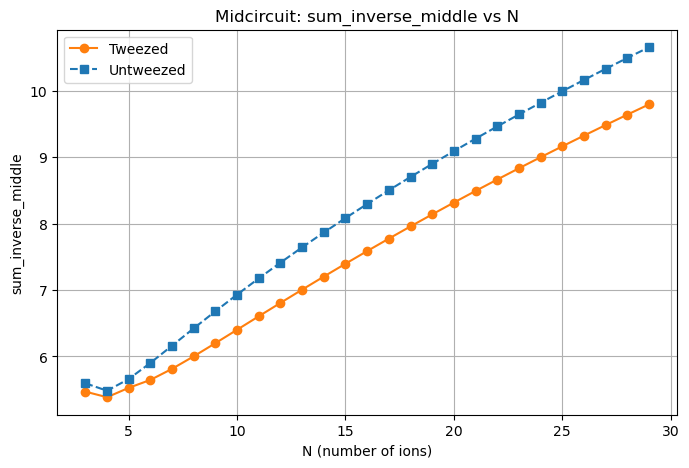

In [32]:
N = np.arange(3,4)
P = [1e-3]
w0 = 1e-6
f_rf_r = 1e6
f_rf_a = f_rf_r/3

dfs = []
many_N = []

for N in range(3, 30):
    test_loop = midcircuit_modes(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs.append(df)



# ...existing code...
dfs_untweezed = []
many_N_untweezed = []

for N in range(3, 30):
    test_loop = midcircuit_modes_untweezed(
        omega_tweezer,
        linewidths,
        omega_res,
        m,
        mode_calc_r,
        N,
        f_rf_r,
        f_rf_a,
        P,
        w0,
    )
    many_N_untweezed.append((N, test_loop))

    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N)
        # attempt to coerce Tweezed Ion to int when safe
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        # NOTE: do NOT dedupe here — keep all rows including symmetric duplicates
        dfs_untweezed.append(df)
# combine per-N DataFrames if not already done

combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

Ns_t, vals_t = first_sum_by_N(combined_df)
Ns_u, vals_u = first_sum_by_N(combined_untweezed)

plt.figure(figsize=(8,5))
if Ns_t.size:
    plt.plot(Ns_t, vals_t, marker='o', linestyle='-', color='C1', label='Tweezed')
if Ns_u.size:
    plt.plot(Ns_u, vals_u, marker='s', linestyle='--', color='C0', label='Untweezed')
plt.xlabel("N (number of ions)")
plt.ylabel("sum_inverse_middle")
plt.title("Midcircuit: sum_inverse_middle vs N")
plt.grid(True)
plt.legend()
plt.show()

In [33]:
many_N

[(3,
     Tweezed Ion  Coolant Ion                                                 Mode couplings                                        inverse_mode_couplings  sum_inverse_middle
  0          1.0            0  [0.5454114492630452, -0.7071067811866492, 0.4500292779505079]  [1.8334781958669746, 1.4142135623728918, 2.2220776491568075]            5.469769),
 (4,
     Tweezed Ion  Coolant Ion                                                 Mode couplings                                        inverse_mode_couplings  sum_inverse_middle
  0          1.0            0  [0.4984147087774989, -0.6357302805258692, 0.5536624942893394]  [2.0063613340239876, 1.5729941307386064, 1.8061544899904458]             5.38551
  1          2.0            3   [0.4984147087775866, 0.6357302805262881, 0.5536624942890477]  [2.0063613340236346, 1.5729941307375699, 1.8061544899913975]             5.38551),
 (5,
     Tweezed Ion  Coolant Ion                                                   Mode couplings            

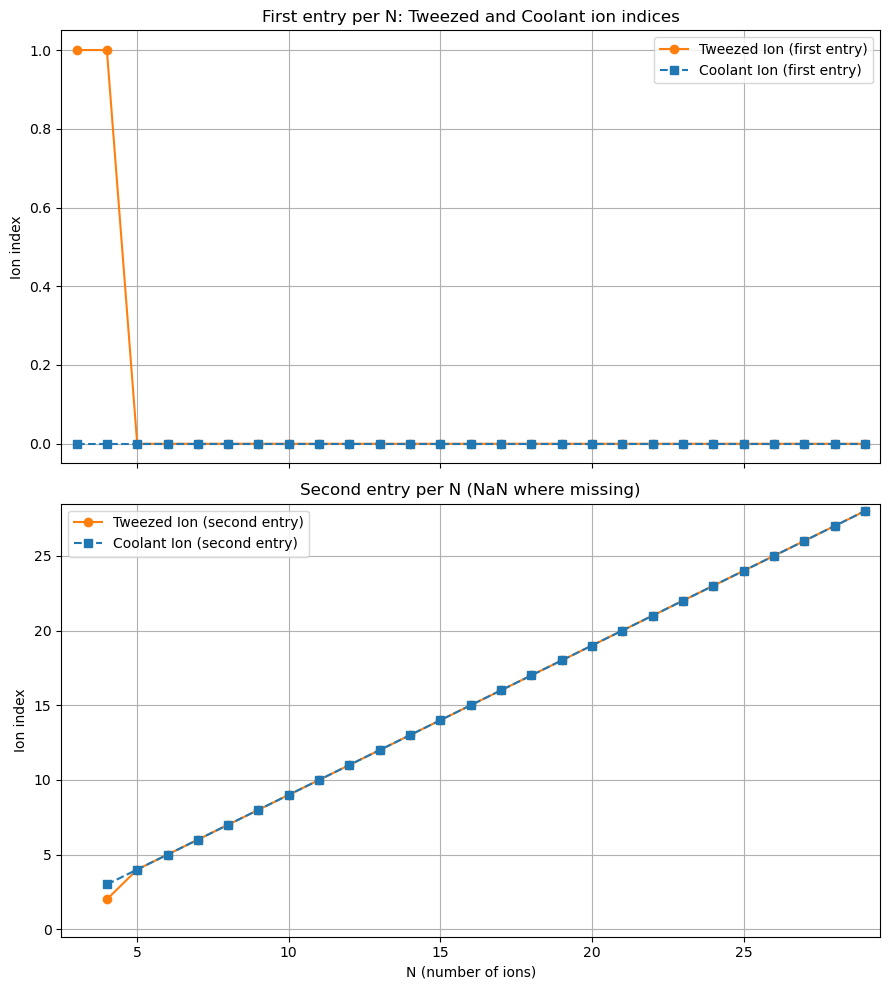

In [36]:
# ...existing code...
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def _get_df_for_N(many, combined, N):
    if isinstance(many, list):
        for n, item in many:
            if n == N:
                if isinstance(item, pd.DataFrame):
                    return item.copy().reset_index(drop=True)
                return None
    if isinstance(combined, pd.DataFrame) and not combined.empty:
        tmp = combined[combined['N'] == N]
        if not tmp.empty:
            return tmp.copy().reset_index(drop=True)
    return None

many = globals().get('many_N')
combined = globals().get('combined_df')

if isinstance(many, list) and many:
    Ns = sorted({n for n, _ in many})
elif isinstance(combined, pd.DataFrame) and not combined.empty and 'N' in combined.columns:
    Ns = sorted(combined['N'].unique())
else:
    Ns = list(range(3, 30))

Ns = list(Ns)
first_t = []
first_c = []
second_t = []
second_c = []

for N in Ns:
    df = _get_df_for_N(many, combined, N)
    if df is None or df.empty:
        first_t.append(np.nan); first_c.append(np.nan)
        second_t.append(np.nan); second_c.append(np.nan)
        continue

    def safe_int(x):
        try:
            return int(x)
        except Exception:
            try:
                return int(float(x))
            except Exception:
                return np.nan

    # first entry (row 0)
    r0 = df.iloc[0]
    first_t.append(safe_int(r0.get('Tweezed Ion', np.nan)))
    first_c.append(safe_int(r0.get('Coolant Ion', np.nan)))

    # second entry (row 1) if available
    if len(df) > 1:
        r1 = df.iloc[1]
        second_t.append(safe_int(r1.get('Tweezed Ion', np.nan)))
        second_c.append(safe_int(r1.get('Coolant Ion', np.nan)))
    else:
        second_t.append(np.nan); second_c.append(np.nan)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(9,10), sharex=True)

axes[0].plot(Ns, first_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (first entry)')
axes[0].plot(Ns, first_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (first entry)')
axes[0].set_ylabel('Ion index')
axes[0].set_title('First entry per N: Tweezed and Coolant ion indices')
axes[0].grid(True)
axes[0].legend()

axes[1].plot(Ns, second_t, marker='o', linestyle='-', color='C1', label='Tweezed Ion (second entry)')
axes[1].plot(Ns, second_c, marker='s', linestyle='--', color='C0', label='Coolant Ion (second entry)')
axes[1].set_xlabel('N (number of ions)')
axes[1].set_ylabel('Ion index')
axes[1].set_title('Second entry per N (NaN where missing)')
axes[1].grid(True)
axes[1].legend()

plt.xlim(min(Ns)-0.5, max(Ns)+0.5)
valid_vals = [v for v in (first_t + first_c + second_t + second_c) if not np.isnan(v)]
if valid_vals:
    plt.ylim(-0.5, max(valid_vals) + 0.5)

plt.tight_layout()
plt.show()


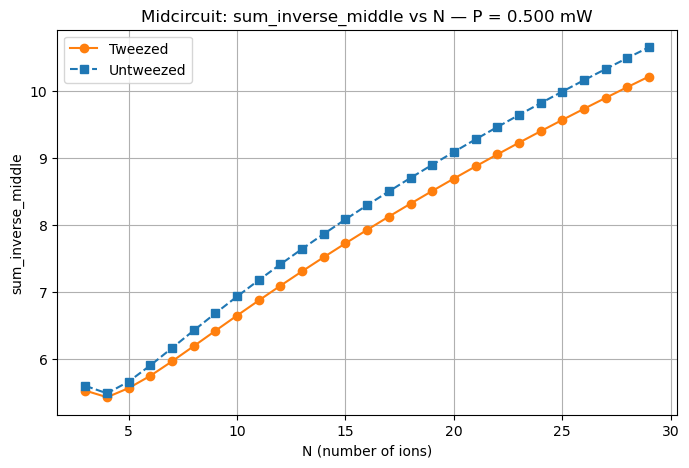

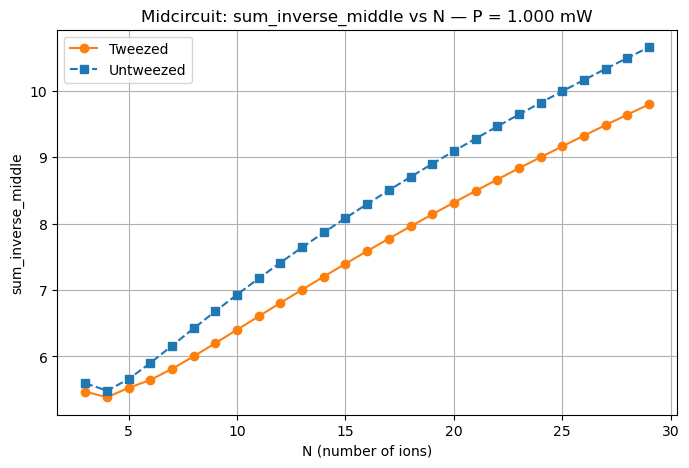

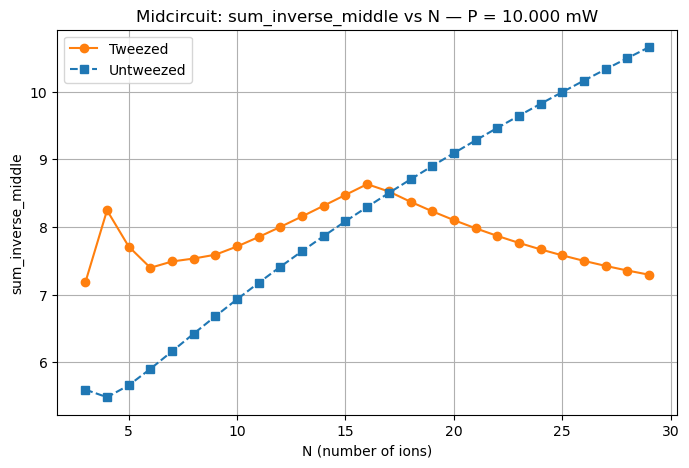

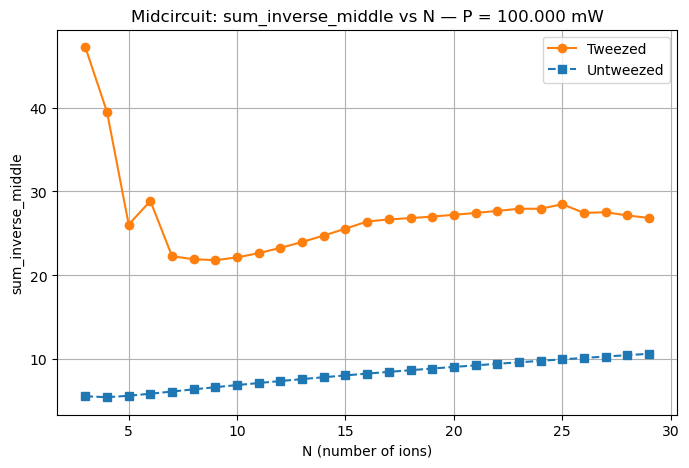

In [93]:
# ...existing code...
# loop over powers and plot per-power figure
import numpy as np
import matplotlib.pyplot as plt

# use the requested power list
power_values = [500e-6, 1e-3, 10e-3, 100e-3]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

for p in power_values:
    P_current = [p]    # functions expect a list-like P
    dfs = []
    dfs_untweezed = []
    many_N = []
    many_N_untweezed = []

    for N in range(3, 30):
        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N, f_rf_r, f_rf_a, P_current, w0
        )
        many_N.append((N, test_loop))
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N, f_rf_r, f_rf_a, P_current, w0
        )
        many_N_untweezed.append((N, test_loop_u))
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

    combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
    combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()


    Ns_t, vals_t = first_sum_by_N(combined_df)
    Ns_u, vals_u = first_sum_by_N(combined_untweezed)

    plt.figure(figsize=(8,5))
    if Ns_t.size:
        plt.plot(Ns_t, vals_t, marker='o', linestyle='-', color='C1', label='Tweezed')
    if Ns_u.size:
        plt.plot(Ns_u, vals_u, marker='s', linestyle='--', color='C0', label='Untweezed')
    plt.xlabel("N (number of ions)")
    plt.ylabel("sum_inverse_middle")
    # show power in mW instead of W
    plt.title(f"Midcircuit: sum_inverse_middle vs N — P = {p*1e3:.3f} mW")
    plt.grid(True)
    plt.legend()
    plt.show()
# ...existing code...

for N=10,N=20,N=30, what is the ratio of tweezed and untweezed as a function of power


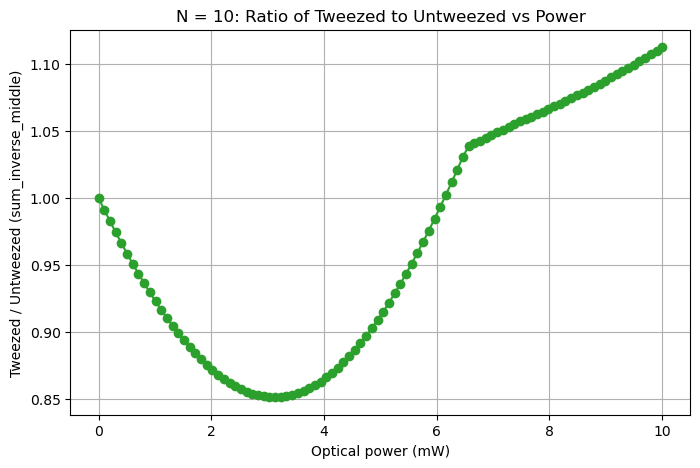

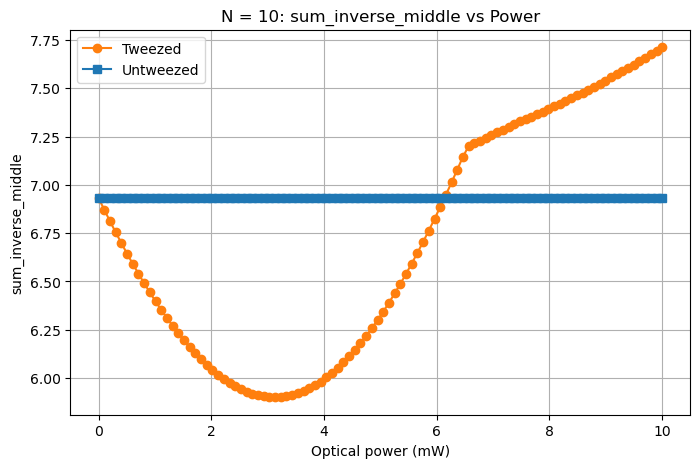

In [94]:
# ...existing code...
# fix N=10, sweep power and plot tweezed/untweezed ratio vs power
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6,10e-3,100)
N_fixed = 10

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = []
ratio_vals = []
t_vals = []
u_vals = []

for p in power_values:
    P_current = [p]
    dfs = []
    dfs_untweezed = []

    # only evaluate for fixed N
    test_loop = midcircuit_modes(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_fixed, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
        df = test_loop.copy().reset_index(drop=True)
        df['N'] = int(N_fixed)
        try:
            df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs.append(df)

    test_loop_u = midcircuit_modes_untweezed(
        omega_tweezer, linewidths, omega_res, m, mode_calc_r,
        N_fixed, f_rf_r, f_rf_a, P_current, w0
    )
    if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
        dfu = test_loop_u.copy().reset_index(drop=True)
        dfu['N'] = int(N_fixed)
        try:
            dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
        except Exception:
            pass
        dfs_untweezed.append(dfu)

    combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
    combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

    _, vals_t = first_sum_by_N(combined_df)
    _, vals_u = first_sum_by_N(combined_untweezed)

    # pick first (only) entry if present
    val_t = vals_t[0] if vals_t.size else np.nan
    val_u = vals_u[0] if vals_u.size else np.nan

    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = np.nan if np.isnan(val_t) and np.isnan(val_u) else (np.nan if val_u == 0 else (val_t / val_u))

    powers_mW.append(p * 1e3)
    ratio_vals.append(ratio)
    t_vals.append(val_t)
    u_vals.append(val_u)

# plot ratio vs power (x in mW)
plt.figure(figsize=(8,5))
plt.plot(powers_mW, ratio_vals, marker='o', linestyle='-', color='C2')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title(f"N = {N_fixed}: Ratio of Tweezed to Untweezed vs Power")
plt.grid(True)
plt.show()

# optional: also show raw values
plt.figure(figsize=(8,5))
plt.plot(powers_mW, t_vals, marker='o', label='Tweezed', color='C1')
plt.plot(powers_mW, u_vals, marker='s', label='Untweezed', color='C0')
plt.xlabel("Optical power (mW)")
plt.ylabel("sum_inverse_middle")
plt.title(f"N = {N_fixed}: sum_inverse_middle vs Power")
plt.legend()
plt.grid(True)
plt.show()
# ...existing code...

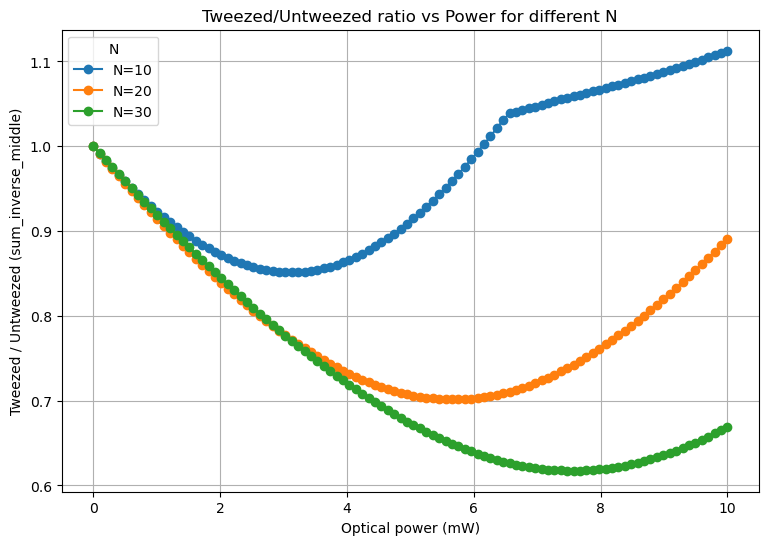

In [95]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 10e-3, 100)
Ns_to_plot = [10, 20, 30]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)

# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()


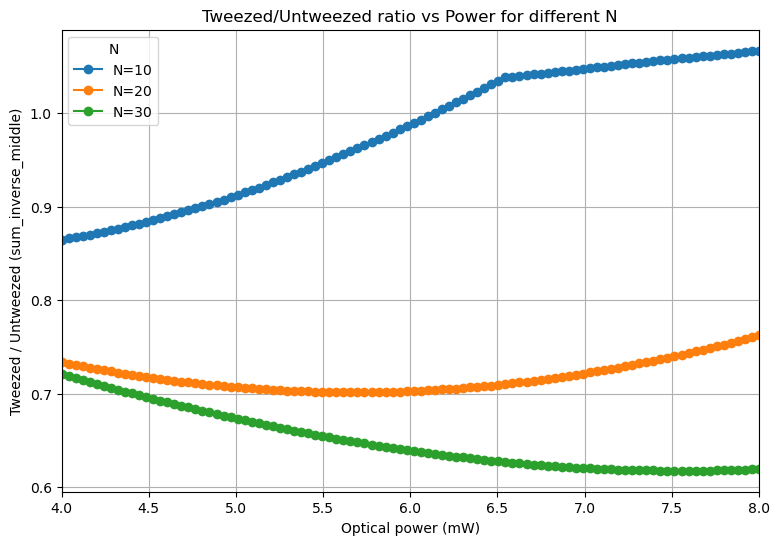

In [96]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values_zoomed_in = np.linspace(4e-3, 8e-3, 100)
Ns_to_plot = [10, 20, 30]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values_zoomed_in * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values_zoomed_in:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)

# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.xlim(min(powers_mW), max(powers_mW))
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()


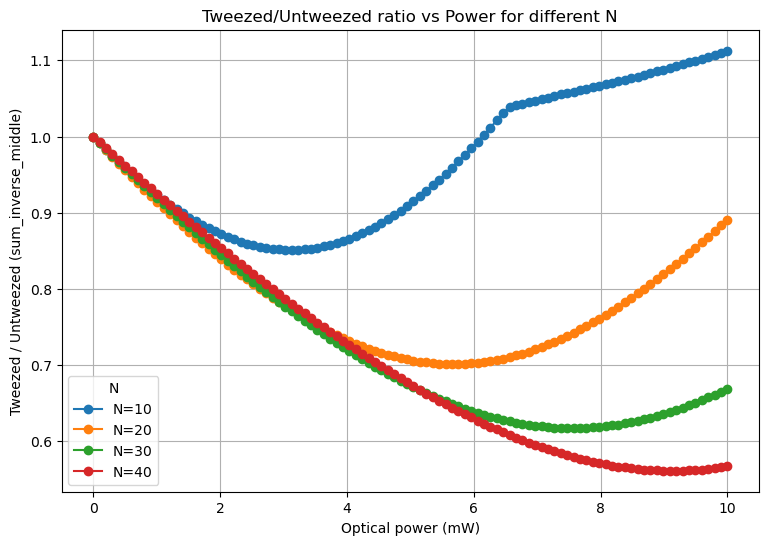

In [97]:
# ...existing code...
# fix N=10,20,30 sweep power and plot tweezed/untweezed ratio vs power (all on same plot)
import numpy as np
import matplotlib.pyplot as plt

power_values = np.linspace(1e-6, 10e-3, 100)
Ns_to_plot = [10, 20, 30,40]

def first_sum_by_N(df):
    if df is None or df.empty:
        return np.array([]), np.array([])
    first = df.groupby("N", sort=True, as_index=False).first()
    return first["N"].to_numpy(), first["sum_inverse_middle"].to_numpy()

powers_mW = (power_values * 1e3).tolist()

# prepare containers per N
t_vals = {N: [] for N in Ns_to_plot}
u_vals = {N: [] for N in Ns_to_plot}
ratio_vals = {N: [] for N in Ns_to_plot}

for p in power_values:
    P_current = [p]
    for N_fixed in Ns_to_plot:
        dfs = []
        dfs_untweezed = []

        # tweezed
        test_loop = midcircuit_modes(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop, pd.DataFrame) and not test_loop.empty:
            df = test_loop.copy().reset_index(drop=True)
            df['N'] = int(N_fixed)
            try:
                df['Tweezed Ion'] = df['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs.append(df)

        # untweezed
        test_loop_u = midcircuit_modes_untweezed(
            omega_tweezer, linewidths, omega_res, m, mode_calc_r,
            N_fixed, f_rf_r, f_rf_a, P_current, w0
        )
        if isinstance(test_loop_u, pd.DataFrame) and not test_loop_u.empty:
            dfu = test_loop_u.copy().reset_index(drop=True)
            dfu['N'] = int(N_fixed)
            try:
                dfu['Tweezed Ion'] = dfu['Tweezed Ion'].astype(int)
            except Exception:
                pass
            dfs_untweezed.append(dfu)

        combined_df = pd.concat(dfs, ignore_index=True, sort=False) if dfs else pd.DataFrame()
        combined_untweezed = pd.concat(dfs_untweezed, ignore_index=True, sort=False) if dfs_untweezed else pd.DataFrame()

        _, vals_t_arr = first_sum_by_N(combined_df)
        _, vals_u_arr = first_sum_by_N(combined_untweezed)

        val_t = vals_t_arr[0] if vals_t_arr.size else np.nan
        val_u = vals_u_arr[0] if vals_u_arr.size else np.nan

        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = np.nan if (np.isnan(val_t) and np.isnan(val_u)) else (np.nan if val_u == 0 else (val_t / val_u))

        t_vals[N_fixed].append(val_t)
        u_vals[N_fixed].append(val_u)
        ratio_vals[N_fixed].append(ratio)

# --- Plot: ratio curves for N=10,20,30 on same axes ---
plt.figure(figsize=(9,6))
colors = plt.cm.tab10.colors
for i, N_fixed in enumerate(Ns_to_plot):
    plt.plot(powers_mW, ratio_vals[N_fixed], marker='o', linestyle='-', color=colors[i % len(colors)],
             label=f'N={N_fixed}')
plt.xlabel("Optical power (mW)")
plt.ylabel("Tweezed / Untweezed (sum_inverse_middle)")
plt.title("Tweezed/Untweezed ratio vs Power for different N")
plt.grid(True)
plt.legend(title="N")
plt.show()
